# ***Feature Engineering*: Variables de clima y Complejidad del pedido**

## **1. Objetivo**

El objetivo de este notebook es enriquecer el dataset operacional de Glovo mediante la creación de nuevas variables  que puedan mejorar la capacidad predictiva del modelo de tiempo de entrega.

En particular, se incorporan dos grupos de variables:

- **Variables meteorológicas**

Se añaden datos climáticos históricos asociados al momento y ubicación de cada pedido:

    - Código meteorológico (weather_code)
    - Descripción textual del clima (weather_desc)
    - Nivel de precipitación (precip_mm)

Estas variables permiten capturar condiciones externas que afectan directamente la logística de entrega, como lluvia, niebla o tormentas.

- **Variables de complejidad del pedido**

Se extraen métricas estructuradas a partir del texto descriptivo del pedido:

    - Total_Unidades: número total de unidades solicitadas
    - Articulos_Distintos: cantidad de productos diferentes

Estas variables buscan representar la complejidad operativa del pedido, ya que pedidos más grandes o variados pueden aumentar el tiempo de preparación, empaquetado y recogida.

## **2. Metodología**

La construcción de variables se divide en dos etapas principales:
- Enriquecimiento meteorológico mediante Open-Meteo
- Extracción de métricas de complejidad del pedido usando procesamiento de texto

Librerías utilizadas:

In [ ]:
pip install openmeteo-requests requests-cache retry-requests pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.9/208.9 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 753.6/753.6 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.1/128.1 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 399.4/399.4 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 60.7 MB/s eta 0:00:00
  Attempting uninstall: flatbuffers
    Found existing installation: flatbuffers 25.12.19
    Uninstalling flatbuffers-25.12.19:
      Successfully uninstalled flatbuffers-25.12.19


In [ ]:
import pandas as pd
import numpy as np
import openmeteo_requests
import requests_cache
from retry_requests import retry
from tqdm.auto import tqdm
import time
import re

import matplotlib.pyplot as plt
import seaborn as sns

Carga del dataset:

In [ ]:
df = pd.read_csv('glovo_ops_data_final.csv')
df_mod = df.copy()

## **3. Ingeniería de variables meteorológicas**

### **3.1 Motivación**

Las condiciones meteorológicas tienen un impacto significativo sobre los tiempos de entrega en operaciones de última milla. Factores como lluvia, niebla o tormentas pueden afectar la velocidad de circulación, aumentar la congestión y generar retrasos operacionales.

Por ello, incorporar información climática al dataset puede aportar señal predictiva relevante para mejorar la estimación del tiempo de entrega.

En esta sección se construye un pipeline para enriquecer el dataset con variables meteorológicas históricas utilizando la API de Open-Meteo.

### **3.2 Metodología**

El proceso de ingeniería de variables meteorológicas se compone de cinco etapas principales:

**1.**   Configuración de la API y sistema de caché

**2.**  Preparación de eventos únicos

**3.**   Extracción de información climática

**4.**   Descarga masiva de datos

**5.**   Integración y limpieza final

In [ ]:
# 1. CONFIGURACIÓN DE API Y MAPEO
print("🚀 Iniciando configuración de la API y caché...")
cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
retry_session = retry(cache_session, retries=10, backoff_factor=0.5)
openmeteo = openmeteo_requests.Client(session=retry_session)

# Diccionario de códigos meteorológicos
wmo_description = {
    0: "Despejado", 1: "Principalmente despejado", 2: "Parcialmente nublado", 3: "Nublado",
    45: "Niebla", 48: "Niebla rima", 51: "Llovizna ligera", 53: "Llovizna moderada",
    55: "Llovizna densa", 61: "Lluvia ligera", 63: "Lluvia moderada", 65: "Lluvia fuerte",
    71: "Nieve ligera", 73: "Nieve moderada", 75: "Nieve fuerte", 77: "Granizo",
    80: "Chubascos ligeros", 81: "Chubascos moderados", 82: "Chubascos violentos"
}

# 2. PREPARACIÓN DE EVENTOS ÚNICOS
print("🔍 Analizando el dataset para identificar eventos únicos (lat/lon/hora)...")
# Redondeamos para agrupar y ganar eficiencia
df_mod['lat_round'] = df_mod['pickup_latitude'].round(2)
df_mod['lon_round'] = df_mod['pickup_longitude'].round(2)
df_mod['hour_round'] = pd.to_datetime(df_mod['activation_time_local']).dt.floor('H')

eventos_unicos = df_mod[['lat_round', 'lon_round', 'hour_round']].drop_duplicates().copy()

print(f"📊 Registros totales: {len(df_mod)}")
print(f"🎯 Peticiones únicas a realizar: {len(eventos_unicos)} (Reducción de carga: {100 - (len(eventos_unicos)/len(df_mod)*100):.1f}%)")

# 3. FUNCIÓN DE EXTRACCIÓN
def get_weather_data(row):
    date_str = row['hour_round'].strftime('%Y-%m-%d')
    hour_idx = row['hour_round'].hour
    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": row['lat_round'],
        "longitude": row['lon_round'],
        "start_date": date_str,
        "end_date": date_str,
        "hourly": ["weather_code", "precipitation"],
        "timezone": "auto"
    }

    try:
        responses = openmeteo.weather_api(url, params=params)
        hourly = responses[0].Hourly()
        code = hourly.Variables(0).ValuesAsNumpy()[hour_idx]
        precip = hourly.Variables(1).ValuesAsNumpy()[hour_idx]
        return int(code), float(precip)
    except Exception:
        return np.nan, np.nan

# 4. EJECUCIÓN CON BARRA DE PROGRESO
print("\n⏳ Iniciando descarga de datos meteorológicos desde Open-Meteo...")
# Activamos el soporte de tqdm para pandas
tqdm.pandas(desc="Progreso de Descarga")

eventos_unicos[['weather_code', 'precip_mm']] = eventos_unicos.progress_apply(
    lambda x: pd.Series(get_weather_data(x)), axis=1
)

# 5. MERGE Y FINALIZACIÓN
print("\n🔗 Uniendo datos climáticos con el dataset principal...")
df_mod = df_mod.merge(eventos_unicos, on=['lat_round', 'lon_round', 'hour_round'], how='left')

print("🏷️ Mapeando códigos a descripciones textuales...")
df_mod['weather_desc'] = df_mod['weather_code'].map(wmo_description)

print("🧹 Limpiando columnas de procesamiento...")
df_mod = df_mod.drop(columns=['lat_round', 'lon_round', 'hour_round'])

print("\n✅ ¡Proceso completado! El clima ha sido asignado correctamente.")

## **4. Ingeniería de variables del pedido**

### **4.1 Motivación**

La complejidad del pedido puede afectar directamente el tiempo de entrega.

Pedidos con muchas unidades, múltiples productos, mayor volumen, requieren generalmente más tiempo de preparación, empaquetado más complejo y/o mayor tiempo de recogida.

Por ello se construyen variables representativas de dicha complejidad.

### **4.2 Lógica implementada**

La variable description contiene información textual semiestructurada sobre los productos incluidos en cada pedido. Sin embargo, el formato no es homogéneo: algunas descripciones incluyen cantidades explícitas, otras contienen texto libre, direcciones o instrucciones adicionales.

Por ello, se implementa una función de procesamiento textual cuyo objetivo es inferir automáticamente dos métricas operativas:

- `Total_Unidades`: cantidad total de unidades solicitadas.
- `Articulos_Distintos`: número de productos diferentes presentes en el pedido.

In [ ]:
# La función procesa el campo textual description para inferir estructura del pedido
def extraer_metricas_pedido_pro(texto):
    # 1. Validación inicial
    if pd.isna(texto) or str(texto).strip() == "":
        return 1, 1

    lineas = str(texto).split('\n')
    total_unidades = 0
    articulos_diferentes = 0

    # 2. Filtrado de ruido
    # Palabras clave para ignorar (direcciones, teléfonos, etc.)
    stop_words = ['tel', 'contact', 'rue', 'avenue', 'code', 'appel', 'sonnez', 'porte', 'chesneau']

    for linea in lineas:
        linea = linea.strip()
        if not linea: continue

        linea_lower = linea.lower()
        if any(word in linea_lower for word in stop_words):
            continue

        # Detección de patrones
        # PATRÓN 1: "1 x Pizza" o "99 x Pizza"
        match_x = re.search(r'^(\d{1,2})(?!\d)\s*[xX]\s+', linea)

        # PATRÓN 2: "2 classeurs" o "12 croissantes"
        match_num = re.search(r'^(\d{1,2})(?!\d)\s+[a-zA-ZáéíóúÁÉÍÓÚ]+', linea)

        if match_x:
            total_unidades += int(match_x.group(1))
            articulos_diferentes += 1
        elif match_num:
            total_unidades += int(match_num.group(1))
            articulos_diferentes += 1
        else:
            # Si hay texto pero no hay número al inicio, contamos como 1 unidad
            if not linea.replace(" ", "").isdigit():
                total_unidades += 1
                articulos_diferentes += 1

    return max(total_unidades, 1), max(articulos_diferentes, 1)

# Ejecución
tqdm.pandas(desc="Extrayendo métricas de pedido")

df_mod[['Total_Unidades', 'Articulos_Distintos']] = df_mod['description'].progress_apply(
    lambda x: pd.Series(extraer_metricas_pedido_pro(x))
)

Extrayendo métricas de pedido:   0%|          | 0/63646 [00:00<?, ?it/s]

In [ ]:
df_mod.to_csv('clima_num_articulos.csv', index=False)

### **4.3 Análisis exploratorio de variables creadas**

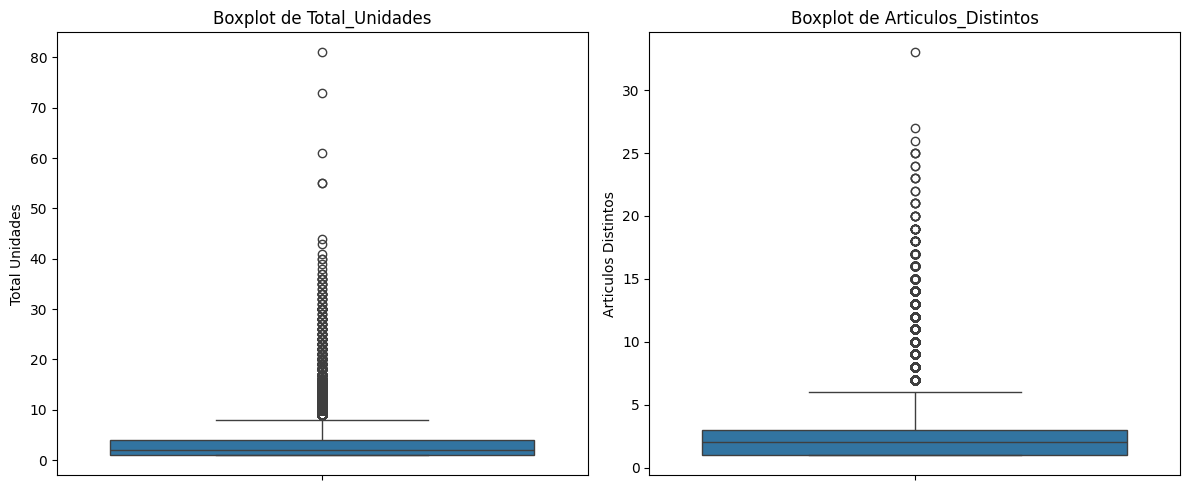

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df_mod['Total_Unidades'])
plt.title('Boxplot de Total_Unidades')
plt.ylabel('Total Unidades')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_mod['Articulos_Distintos'])
plt.title('Boxplot de Articulos_Distintos')
plt.ylabel('Articulos Distintos')

plt.tight_layout()
plt.show()

In [ ]:
print(df_mod[['Total_Unidades', 'Articulos_Distintos']].describe())

       Total_Unidades  Articulos_Distintos
count    63646.000000         63646.000000
mean         3.368020             2.699038
std          3.354108             2.389078
min          1.000000             1.000000
25%          1.000000             1.000000
50%          2.000000             2.000000
75%          4.000000             3.000000
max         81.000000            33.000000


- **Distribución de `Total_Unidades`**

La distribución del número total de unidades muestra que la mayoría de pedidos contienen pocas unidades, la mediana se sitúa en 2. Existen outliers significativos, y se observan pedidos extremos de hasta 81 unidades. Esto sugiere una distribución fuertemente asimétrica hacia la derecha.

- **Distribución de `Articulos_Distintos`**

La mayoría de pedidos contienen entre 1 y 3 productos distintos.
Existen pedidos excepcionalmente complejos con más de 20 artículos diferentes.
La variable también presenta fuerte *skew* positivo.

Extraemos una muestra para revisar si los resultados tienen sentido.

In [ ]:
sample_df = df_mod.sample(n=50, random_state=42) # random_state para reproducibilidad
sample_df = sample_df[['description', 'Total_Unidades', 'Articulos_Distintos']]
sample_df.head(50)

,description,Total_Unidades,Articulos_Distintos
59523,"1 x Caffe Latte - Grande, Espresso Roast Cla...",1,1
7024,1 x Raviolis aux herbes et au porc (10 p) (vap...,1,1
55994,2 Robes,2,1
63217,1 x 320 - Keng kiewwan jé - Pâtes de riz saut...,1,1
22408,Récupérer un paquet pour Camille Amar,1,1
12335,1 x Pascal\n1 x Zola,2,2
55363,1 x Coffret de 49 chocolats,1,1
15101,1 x Champagne Mumm,1,1
51981,1 x Cupcake aux fruits rouges - Sans Gluten\n1...,13,13
43276,"1 x Curry vert - Poulet, Riz nature",1,1


- **Mayor cantidad de unidades**

Revisamos que los outliers mayores a 30 hayan sido correctamente categorizados. Se identifica que que los valores 81 y 73 no corresponden a esa cantidad de unidades, por lo que serán tratados más adelante.

In [ ]:
filtered_df = df_mod[df_mod['Total_Unidades'] > 30]
filtered_df = filtered_df[['description', 'Total_Unidades']]
filtered_df.head(50)

,description,Total_Unidades
414,6 x Croissant \n6 x Pain au chocolat\n4 x Pain...,33
853,"2 x Bananes Cavendish -le kilo - 2,27 €\n2 x B...",36
1383,4 x ARPEGGIO x10\n4 x ROMA x10\n4 x LIVANTO x1...,38
2613,2 x Gnocchi pommes de terre -la barquette de 3...,33
3376,16 x L’ Incroyable - Mini\n16 x Le Merveilleu...,32
5302,"4 x Emincé de poulet (250 g - 19,88 €/Kg)\n4 x...",41
5578,6 x Sushi saumon et avocat\n5 x Salade de chou...,37
9836,2 x Café\n2 x Vanille de Madagascar\n3 x Rose ...,39
9910,10 croissants \n10 pains au chocolat \n2 brioc...,61
10358,Expediteur :\nLavinia Madeleine\n \nTel : +331...,81


- **Mayor cantidad de artículos distintos**

Se revisan los pedidos con artículos diferentes mayores a 20. Se identifica que en estos casos, cada uno de los valores han sido asigandos de manera correcta.

In [ ]:
filtered_df = df_mod[df_mod['Articulos_Distintos'] > 20]
filtered_df = filtered_df[['description', 'Articulos_Distintos']]
filtered_df.head(50)

,description,Articulos_Distintos
1085,1 x Beurre tendre president 125g\n1 x Huile d'...,21
2613,2 x Gnocchi pommes de terre -la barquette de 3...,25
3650,2 x Plat cuisiné saucisses lentilles CARREFOUR...,22
7214,1 x Steaks haches bio 15% mg charal\n1 x Beurr...,23
11065,1 x Kiwi vert Bio (1 pièce)\n1 x Pomme Bio (50...,24
11285,1 x Finger lait 138g cadbury\n2 x P11 kinder m...,25
19356,1 x Gel douche Nutrition Intense DOVE - le fla...,23
19695,1 x Barre lion 42g nestle\n1 x Barre mars\n2 x...,22
22392,1 x Datte medjoul - 500g\n1 x Citron jaune - 5...,26
25970,1 x Chips pesto parmesan TYRRELLS-le paquet de...,27
